--- Лабораторная работа № 4: Модель гармонического осциллятора ---

In [2]:
using DifferentialEquations, Plots, LaTeXStrings

============================================================================
Задание 1: Гармонический осциллятор без затухания (γ = 0)
Уравнение: ẍ + ω₀² x = 0
============================================================================

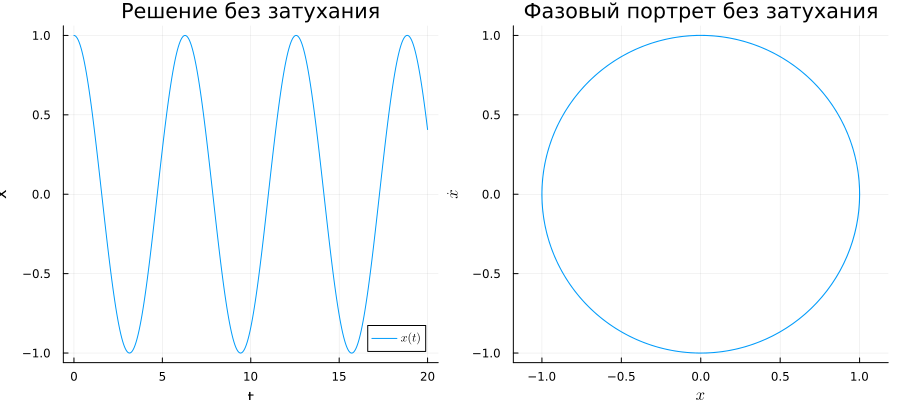

In [4]:
ω₀₁ = 1.0
γ₁ = 0.0

function harmonic_undamped!(du, u, p, t)
    ω₀ = p
    du[1] = u[2]
    du[2] = -ω₀^2 * u[1]
end

u0_undamped = [1.0, 0.0]
tspan_undamped = (0.0, 20.0)
p_undamped = ω₀₁

prob_undamped = ODEProblem(harmonic_undamped!, u0_undamped, tspan_undamped, p_undamped)
sol_undamped = solve(prob_undamped, saveat=0.05)

t_vals = sol_undamped.t
x_vals = [u[1] for u in sol_undamped.u]
v_vals = [u[2] for u in sol_undamped.u]

plot1 = plot(t_vals, x_vals, label=L"x(t)", xlabel="t", ylabel="x", title="Решение без затухания")
plot2 = plot(x_vals, v_vals, label="", xlabel=L"x", ylabel=L"\dot{x}", title="Фазовый портрет без затухания", aspect_ratio=:equal)
plot_undamped = plot(plot1, plot2, layout=(1,2), size=(900,400))

============================================================================
Задание 2: Гармонический осциллятор с затуханием (γ > 0)
Уравнение: ẍ + 2γ ẋ + ω₀² x = 0
============================================================================

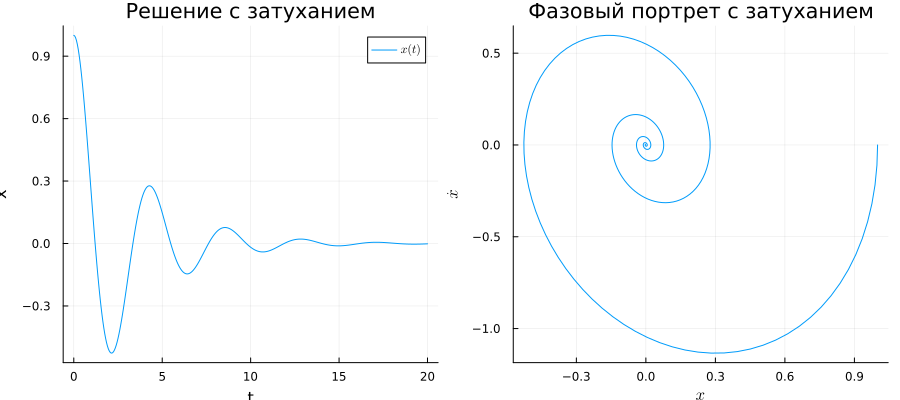

In [6]:
ω₀₂ = 1.5
γ₂ = 0.3

function harmonic_damped!(du, u, p, t)
    ω₀, γ = p
    du[1] = u[2]
    du[2] = -2γ * u[2] - ω₀^2 * u[1]
end

u0_damped = [1.0, 0.0]
tspan_damped = (0.0, 20.0)
p_damped = (ω₀₂, γ₂)

prob_damped = ODEProblem(harmonic_damped!, u0_damped, tspan_damped, p_damped)
sol_damped = solve(prob_damped, saveat=0.05)

t_vals_damp = sol_damped.t
x_vals_damp = [u[1] for u in sol_damped.u]
v_vals_damp = [u[2] for u in sol_damped.u]

plot3 = plot(t_vals_damp, x_vals_damp, label=L"x(t)", xlabel="t", ylabel="x", title="Решение с затуханием")
plot4 = plot(x_vals_damp, v_vals_damp, label="", xlabel=L"x", ylabel=L"\dot{x}", title="Фазовый портрет с затуханием")
plot_damped = plot(plot3, plot4, layout=(1,2), size=(900,400))

============================================================================
Задание 3: Вынужденные колебания гармонического осциллятора
Уравнение: ẍ + 2γ ẋ + ω₀² x = F₀ cos(Ω t)
============================================================================

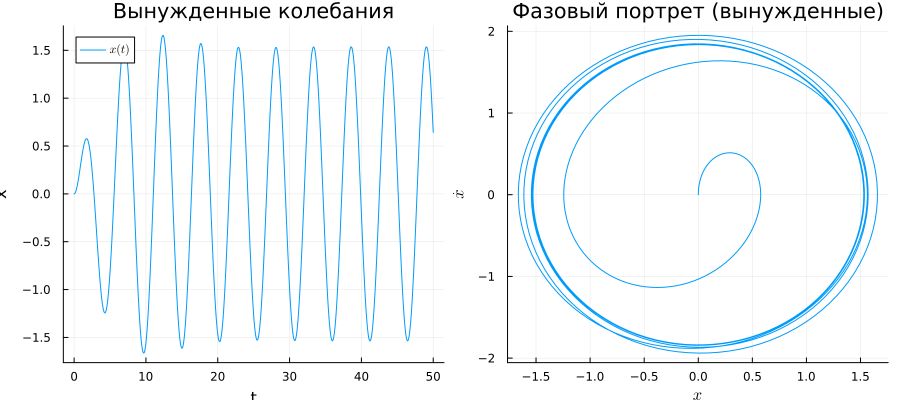

In [8]:
ω₀₃ = 1.0
γ₃ = 0.2
F₀ = 1.0
Ω = 1.2

function harmonic_forced!(du, u, p, t)
    ω₀, γ, F₀, Ω = p
    du[1] = u[2]
    du[2] = -2γ * u[2] - ω₀^2 * u[1] + F₀ * cos(Ω * t)
end

u0_forced = [0.0, 0.0]
tspan_forced = (0.0, 50.0)
p_forced = (ω₀₃, γ₃, F₀, Ω)

prob_forced = ODEProblem(harmonic_forced!, u0_forced, tspan_forced, p_forced)
sol_forced = solve(prob_forced, saveat=0.05)

t_vals_forced = sol_forced.t
x_vals_forced = [u[1] for u in sol_forced.u]
v_vals_forced = [u[2] for u in sol_forced.u]

plot5 = plot(t_vals_forced, x_vals_forced, label=L"x(t)", xlabel="t", ylabel="x", title="Вынужденные колебания")
plot6 = plot(x_vals_forced, v_vals_forced, label="", xlabel=L"x", ylabel=L"\dot{x}", title="Фазовый портрет (вынужденные)")
plot_forced = plot(plot5, plot6, layout=(1,2), size=(900,400))

============================================================================
Отображение всех графиков
============================================================================

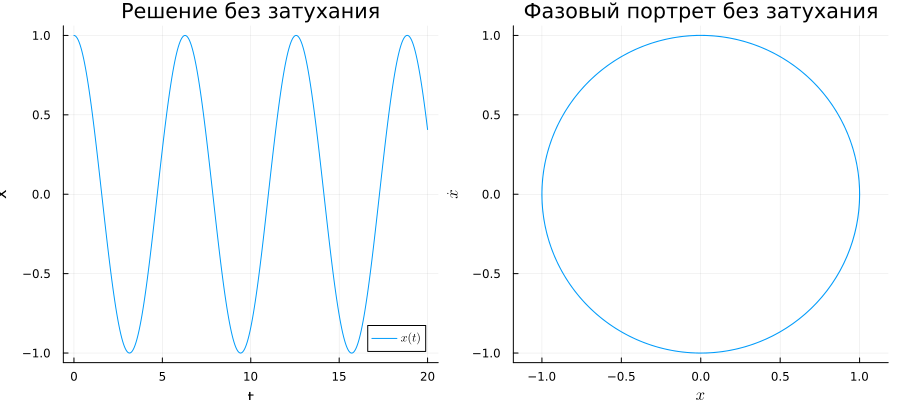

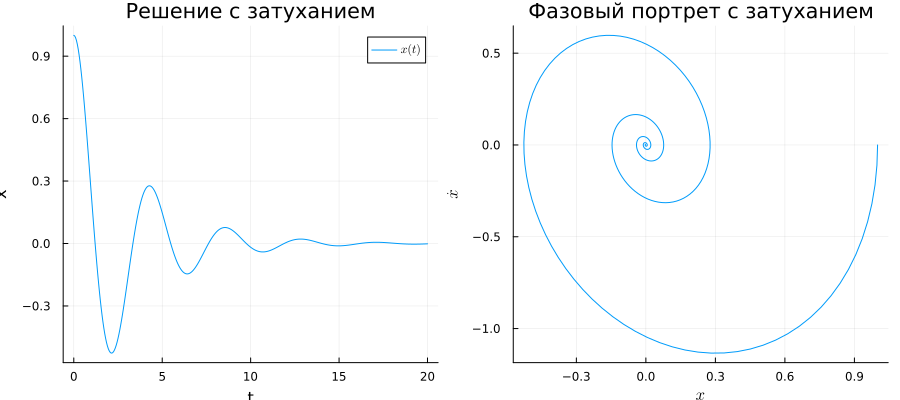

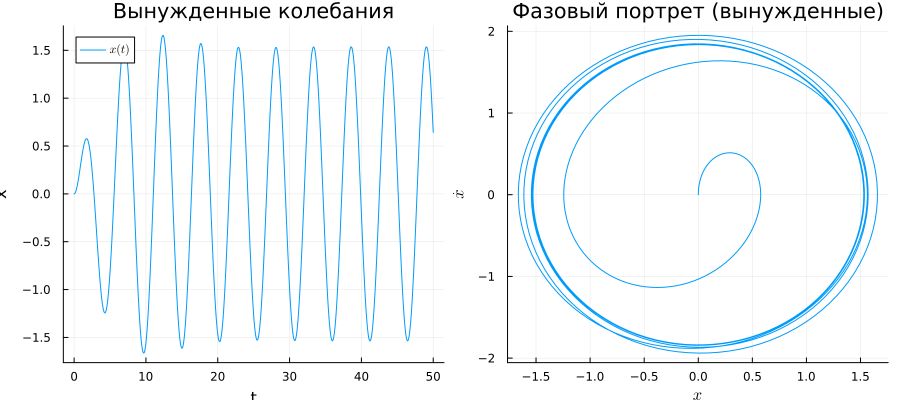

In [10]:
display(plot_undamped)
display(plot_damped)
display(plot_forced)